install visa: https://www.rohde-schwarz.com/us/applications/r-s-visa-application-note_56280-148812.html 

# 1) Start in the Rosetta (Intel) Terminal
In Finder → Applications → Utilities, ⌥ click Terminal.app → Get Info → check “Open using Rosetta”. Open that Rosetta terminal.

# 2) Confirm you're in x86_64 mode
uname -m          # this should print: x86_64

# 3) Create and activate a fresh Intel conda env
conda create -n pmm_x86 python=3.10
conda activate pmm_x86
more info at https://medium.com/data-science/how-to-manage-conda-environments-on-an-apple-silicon-m1-mac-1e29cb3bad12

# 4) Install the instrument libraries
pip install RsInstrument pyvisa-py numpy matplotlib

# 5) Add the R&S VISA tools directory to your PATH
export PATH="/Library/Frameworks/RsVisa.framework/Versions/Current/bin:$PATH"

# 6) Reboot the Mac once, then—still in the Rosetta terminal—verify the VNA shows up:
python - <<'PY'
from RsInstrument import RsInstrument
print(RsInstrument.list_resources('?*USB*'))


In [1]:
from RsInstrument import *
import time
import numpy as np
import matplotlib.pyplot as plt

# Use the instr_list string items as resource names in the RsInstrument constructor
instr_list = RsInstrument.list_resources("?*")
print(instr_list)

('TCPIP0::::inst0::INSTR', 'USB0::0x0AAD::0x01C0::101603::INSTR', 'ASRL0::INSTR', 'ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR')


In [5]:
instr = RsInstrument('USB0::0x0AAD::0x01C0::101603::INSTR', True, True)

idn = instr.query_str('*IDN?')
print(f"\nHello, I am: '{idn}'")
print(f'RsInstrument driver version: {instr.driver_version}')
print(f'Visa manufacturer: {instr.visa_manufacturer}')
print(f'Instrument full name: {instr.full_instrument_model_name}')
print(f'Instrument installed options: {",".join(instr.instrument_options)}')
instr.write_str('SENSe1:FREQuency:STARt 2.0GHZ')  # Start frequency to 10 MHz
instr.write_str('SENSe1:FREQuency:STOP 12.0GHZ')
print(instr.query_str("SENSe:FREQuency:STARt?"))
print(instr.query_str("SENSe:FREQuency:STOP?"))
instr.write('SENSe1:SWEep:POINts 10000')
instr.write_str_with_opc("INIT1:CONT ON")
instr.write_str('CALCulate1:PARameter:MEASure "Trc1", "S21"')
instr.write_str('DISPlay:WINDow1:TRACe1:Y:SCALe:AUTO ONCE')  # Enable auto scaling for trace 1
instr.write_str_with_opc("INIT1:CONT OFF")  # Set single sweep mode and stop acquisition
trace_data = instr.query_str('CALC1:DATA? FDAT')
trace_tup = list(map(str, trace_data.split(',')))
# Close the session
instr.close()


Hello, I am: 'Rohde-Schwarz,ZNB40-4Port,1311601084101603,3.72'
RsInstrument driver version: 1.102.0.112
Visa manufacturer: Rohde & Schwarz GmbH
Instrument full name: ZNB40-4Port
Instrument installed options: B2,B10,B12,B14,B24
2000000000
1.2E+10


# 1) Now bring the VNA back to local.
# 2) Recall last calibration
"channel" (soft key at bottom left) -> "Use cal" -> "recall last cal set"
# 3) Create traces
"trace config" (hard key) -> "meas" (hard key) -> select s-param


In [6]:
instr = RsInstrument('USB0::0x0AAD::0x01C0::101603::INSTR')

traces = instr.query_str('CONFigure:TRACe:CATalog?')
instr.write_str('TRIGger1:SEQuence:SOURce IMM')
time.sleep(5)
t1 = time.time()
S21 = np.array(list(map(str, instr.query_str('CALC1:DATA:TRAC? "Trc1", FDAT').split(','))), dtype = float)
S31 = np.array(list(map(str, instr.query_str('CALC1:DATA:TRAC? "Trc2", FDAT').split(','))), dtype = float)
freq = np.array(list(map(str, instr.query_str('CALC1:DATA:STIM?').split(','))), dtype = float)
instr.write_str('TRIGger1:SEQuence:SOURce MAN')
t2 = time.time()
instr.close()
print(t2-t1, "Seconds to pull data to numpy arrays")

0.020697832107543945 Seconds to pull data to numpy arrays


In [7]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()
inst = rm.open_resource('USB0::0x0AAD::0x01C0::101603::INSTR')
print(inst.query("*IDN?"))
print(inst.query("SENSe:FREQuency:STOP?"))
print(inst.query("SENSe:FREQuency:STOP?"))
#inst.write("*rst")

ValueError: Could not locate a VISA implementation. Install either the IVI binary or pyvisa-py.

In [8]:
S21

array([-68.55175797, -83.00311042, -83.42665449, -83.73724406,
       -81.99007147, -85.1241203 , -88.26350177, -85.395526  ,
       -85.85082672, -86.57512958, -83.80235114, -85.63543626,
       -84.93842049, -89.20106839, -85.22912105, -75.9582053 ,
       -77.01272132, -67.37139231, -66.25797571, -65.06166462,
       -61.02566672, -58.779247  , -55.51909207, -49.57194077,
       -41.77756754, -36.76499759, -35.45436628, -35.03407992,
       -32.68778794, -30.34750739, -27.77916106, -27.03202755,
       -25.88415208, -24.33338394, -21.72454956, -19.87496978,
       -17.82016555, -16.66627474, -16.36555906, -17.19968577,
       -17.49910382, -16.59233674, -17.59724512, -15.96037999,
       -15.43390247, -16.84644544, -16.0684935 , -15.37519401,
       -16.62073118, -15.6180522 , -14.84122782, -15.32849751,
       -14.74584679, -14.32753165, -14.85716955, -14.55661661,
       -14.61212947, -14.4164805 , -14.6878781 , -15.24401157,
       -15.81066097, -16.0547255 , -15.73926961, -16.11

In [9]:
traces

"'1,Trc1,2,Trc2'"

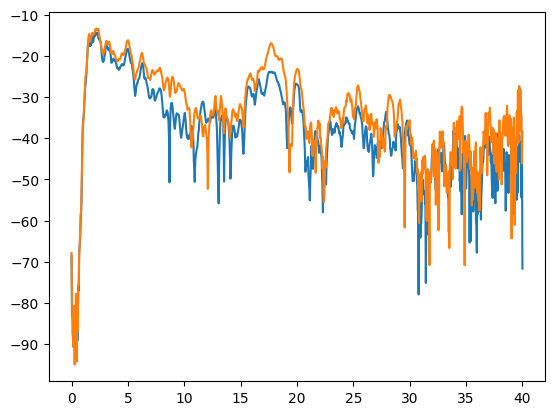

In [10]:
plt.plot(freq/10**9,S21, freq/10**9, S31)

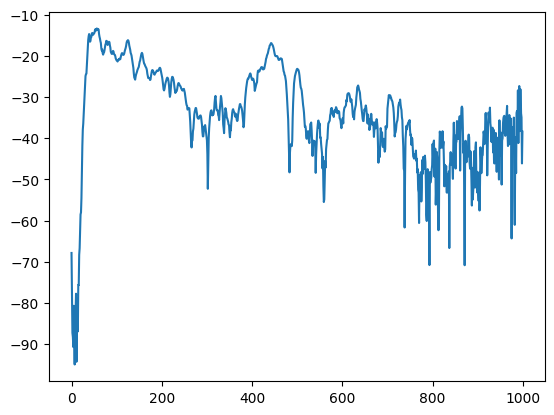

In [11]:
plt.plot(S31)

In [12]:
def Demult_Obj_Comp(freq, S21, S31, f1, f2, df = 0.25, norms = []):
    """
    Compute the demultiplexer objective that is analogous to the computational
    inverse design library. f1 corresponds to port 2, f2 corresponds to port 3.
    
    Args:
        freq: frequency np.array, in GHz
        S21: S21 np.array, in dB
        S31: S31 np.array, in dB
        f1: first operating frequency in GHz
        f2: second operating frequency in GHz
        df: bandwidth around operating frequencies in GHz
        norms: normalization factors
    """
    i1_l = np.searchsorted(freq, f1-df, side='left')
    i1_r = np.searchsorted(freq, f1+df, side='right')
    i2_l = np.searchsorted(freq, f2-df, side='left')
    i2_r = np.searchsorted(freq, f2+df, side='right')
    T21 = np.power(10*np.ones_like(S21), S21/10)
    T31 = np.power(10*np.ones_like(S31), S31/10)
    
    correct_1 = np.sum(T21[i1_l:i1_r])
    incorrect_1 = np.sum(T31[i1_l:i1_r])
    correct_2 = np.sum(T31[i2_l:i2_r])
    incorrect_2 = np.sum(T21[i2_l:i2_r])
    
    if len(norms) > 0:
        c_1 = correct_1/norms[0]
        i_1 = incorrect_1/norms[1]
        c_2 = correct_2/norms[2]
        i_2 = incorrect_2/norms[3]
        return c_1*c_2 - i_1 - i_2, norms
    else:
        new_norms = [np.abs(correct_1), np.abs(incorrect_1),\
                     np.abs(correct_2), np.abs(incorrect_2)]
        return -1, new_norms

In [17]:
def Demult_Obj_dB(freq, S21, S31, f1, f2, df = 0.25, norms = []):
    """
    Compute the demultiplexer objective that focuses more instead on dB
    transmission values. f1 corresponds to port 2, f2 corresponds to port 3.
    
    Args:
        freq: frequency np.array, in GHz
        S21: S21 np.array, in dB
        S31: S31 np.array, in dB
        f1: first operating frequency in GHz
        f2: second operating frequency in GHz
        df: bandwidth around operating frequencies in GHz
        norms: normalization factors
    """
    i1_l = np.searchsorted(freq, f1-df, side='left')
    i1_r = np.searchsorted(freq, f1+df, side='right')
    i2_l = np.searchsorted(freq, f2-df, side='left')
    i2_r = np.searchsorted(freq, f2+df, side='right')
    T21 = np.power(10*np.ones_like(S21), S21/10)
    T31 = np.power(10*np.ones_like(S31), S31/10)
    DdB = S21-S31
    
    correct_1 = np.sum(T21[i1_l:i1_r])
    correct_2 = np.sum(T31[i2_l:i2_r])
    isolation_1 = np.sum(DdB[i1_l:i1_r])
    isolation_2 = np.sum(-DdB[i2_l:i2_r])
    
    if len(norms) > 0:
        c_1 = correct_1/norms[0]
        c_2 = correct_2/norms[1]
        i_1 = isolation_1/norms[2]
        i_2 = isolation_2/norms[3]
        return c_1*c_2 + i_1 + i_2, norms
    else:
        new_norms = [np.abs(correct_1), np.abs(correct_2),\
                     np.abs(isolation_1), np.abs(isolation_2)]
        c_1 = correct_1/new_norms[0]
        c_2 = correct_2/new_norms[1]
        i_1 = isolation_1/new_norms[2]
        i_2 = isolation_2/new_norms[3]
        return c_1*c_2 + i_1 + i_2, new_norms

In [13]:
def Waveguide_Obj_Comp(freq, S21, S31, f, df = 0.25, norms = []):
    """
    Compute the waveguide objective that is analogous to the computational
    inverse design library. Port 2 has to be correct port, otherwise switch
    S21 and S31.
    
    Args:
        freq: frequency np.array, in GHz
        S21: S21 np.array, in dB
        S31: S31 np.array, in dB
        f: operating frequency in GHz
        df: bandwidth around operating frequencies in GHz
        norms: normalization factors
    """
    i_l = np.searchsorted(freq, f-df, side='left')
    i_r = np.searchsorted(freq, f+df, side='right')
    T21 = np.power(10*np.ones_like(S21), S21/10)
    T31 = np.power(10*np.ones_like(S31), S31/10)
    
    correct = np.sum(T21[i_l:i_r])
    incorrect = np.sum(T31[i_l:i_r])
    
    if len(norms) > 0:
        c = correct/norms[0]
        i = incorrect/norms[1]
        return c - i, norms
    else:
        new_norms = [np.abs(correct), np.abs(incorrect)]
        return 0, new_norms

In [38]:
def Waveguide_Obj_dB(freq, S21, S31, f, df = 0.25, norms = []):
    """
    Compute the waveguide objective that focuses more instead on dB
    isolation values. Port 2 has to be correct port, otherwise switch
    S21 and S31.
    
    Args:
        freq: frequency np.array, in GHz
        S21: S21 np.array, in dB
        S31: S31 np.array, in dB
        f: operating frequency in GHz
        df: bandwidth around operating frequencies in GHz
        norms: normalization factors
    """
    i_l = np.searchsorted(freq, f-df, side='left')
    i_r = np.searchsorted(freq, f+df, side='right')
    
    correct = np.sum(S21[i_l:i_r])
    incorrect = np.sum(S31[i_l:i_r])
    
    if len(norms) > 0:
        c = correct/norms[0]
        i = incorrect/norms[1]
        return c - i, norms
    else:
        new_norms = [np.abs(correct), np.abs(incorrect)]
        return 0, new_norms

In [40]:
91//8

11

In [101]:
bulb = np.array([0,1,2,3,4,5])
bulbs_left = 6
rho = np.array([10,20,30,40,50,60])
rhoo = np.row_stack([bulb, rho])
rhoo

array([[ 0,  1,  2,  3,  4,  5],
       [10, 20, 30, 40, 50, 60]])

In [103]:
rhoo = np.row_stack([rhoo, rho])
rhoo

array([[ 0,  1,  2,  3,  4,  5],
       [10, 20, 30, 40, 50, 60],
       [10, 20, 30, 40, 50, 60],
       [10, 20, 30, 40, 50, 60]])

In [67]:
print(bulb)
samp = np.random.choice(bulbs_left,2,replace=False)
print(bulb[samp])
print(rho[bulb[samp]])
bulb = np.delete(bulb, samp)
bulbs_left -= 2

[1 2 3 4]
[3 4]
[40 50]


In [68]:
print(bulb)
samp = np.random.choice(bulbs_left,2,replace=False)
print(bulb[samp])
print(rho[bulb[samp]])
bulb = np.delete(bulb, samp)
bulbs_left -= 2

[1 2]
[2 1]
[30 20]


In [72]:
np.random.normal(0, 0.1, samp.shape)

array([-0.10878943,  0.1909467 ])

In [80]:
f1 = 5.9

In [82]:
"%.1f"%f1

'5.9'

In [ ]:
if int()